## SAFT Equations of State

### PC-SAFT

In [1]:
import yaeos

m = [1.0582, 3.3004]
epsilon_k = [145.5257, 224.0780]
sigma = [3.6316, 3.8639]
model = yaeos.PCSAFT(m, sigma, epsilon_k)

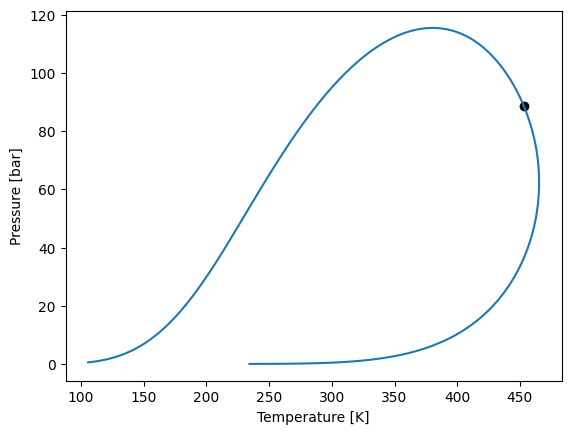

In [2]:
z = [0.5, 0.5]

env = model.phase_envelope_pt(z, kind="dew", p0=0.01)

env.plot()

None


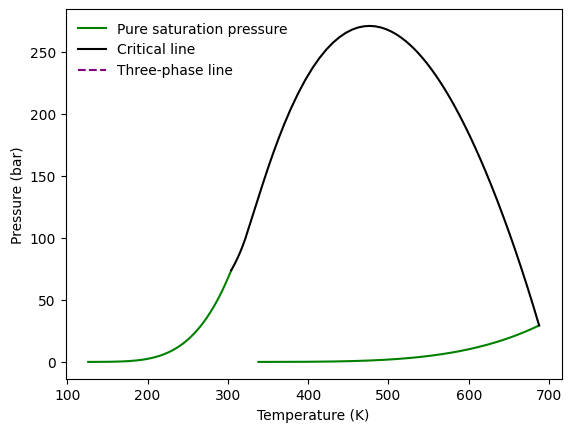

In [3]:
from yaeos import PSRK, GPEC

tc = [304.21, 687.7]
pc = [73.83000000000001, 29.4408]
w = [0.223621, 0.365434205640836]

c1 = [0.8255, 1.06539497171316]
c2 = [0.16755, -0.371283736082231]
c3 = [-1.7039, 0.756295830742416]

groups = [{117: 1}, {1: 2, 2: 3, 3: 1, 7: 1, 138: 1}]

model = PSRK(tc, pc, w, groups, c1, c2, c3)

gpec = GPEC(model, step_21=0.1)
gpec.plot_gped()
print(gpec._cl_ll)

In [4]:
model.critical_line_liquid_liquid?

Signature:
model.critical_line_liquid_liquid(
    z0=[0, 1],
    zi=[1, 0],
    pressure=2000,
    t0=500,
)
Docstring:
Find the start of the Liquid-Liquid critical line of a binary.

Parameters
----------
z0: array_like
    Initial global mole fractions
zi: array_like
    Final global mole fractions
pressure: float
    Pressure [bar]
t0: float
    Initial guess for temperature [K]
File:      ~/docs/programming/python/virtualenvs/thermo/lib/python3.13/site-packages/yaeos/core.py
Type:      method

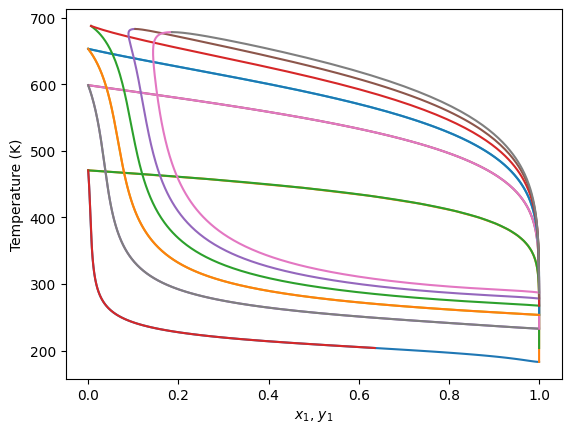

In [5]:
for P in [1, 10, 20, 30, 40, 50]:  
    gpec.plot_txy(P)

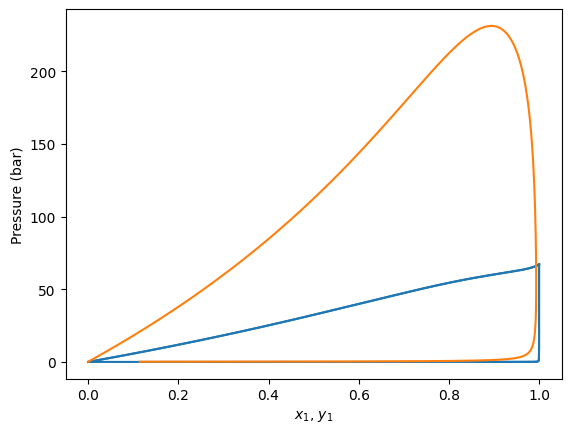

In [6]:
for i, T in enumerate([300, 400]):  
    gpec.plot_pxy(T, color=f"C{i}")